<a href="https://colab.research.google.com/github/juliamota1/CN-unifesp/blob/main/atv1_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 1 - Cálculo numérico
Julia dos Santos Mota

## 1. Objetivos

• calcular erros absoluto, relativo e percentual;

• distinguir truncamento de arredondamento;

• observar a propagação dos erros em cálculos de pressão e vazão;

• produzir gráficos que comuniquem a evolução dos erros;

• explicar por que pequenas variações geométricas podem alterar intensamente o escoamento em um nanocateter.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


In [ ]:
def truncar(numero, casas):
    fator = 10 ** casas
    return math.trunc(numero * fator) / fator

In [ ]:
def erro_absoluto(valor_referencia, valor_aproximado):
  return abs(valor_referencia - valor_aproximado)

def erro_relativo(erro_absoluto, valor_referencia):
  return erro_absoluto / abs(valor_referencia)

def erro_percentual(erro_relativo):
  return 100.0 * erro_relativo

1) aproximação por truncamento e arredondamento

In [ ]:
x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765

valores = [x1, x2, x3]

In [ ]:
for valor_referencia in valores:

  for n in range(5):
    print("")
    valor_trunc = truncar(valor_referencia, n)

    valor_round = round(valor_referencia, n)

    erro_abs_trunc = erro_absoluto(valor_referencia, valor_trunc)
    erro_rel_trunc = erro_relativo(erro_abs_trunc, valor_referencia)
    erro_per_trunc = erro_percentual(erro_rel_trunc)


    erro_abs_round = erro_absoluto(valor_referencia, valor_round)
    erro_rel_round = erro_relativo(erro_abs_round, valor_referencia)
    erro_per_round = erro_percentual(erro_rel_round)


    print(f"Truncado: {valor_trunc}")

    print(f"Ea = {erro_abs_trunc:.10f}")
    print(f"Er = {erro_rel_trunc:.6e}")
    print(f"Ep = {erro_per_trunc:.6f}")

    print(f"Arredondado: {valor_round}")
    print(f"Ea = {erro_abs_round:.10f}")
    print(f"Er = {erro_rel_round:.6e}")
    print(f"Ep = {erro_per_round:.6f}")



Truncado: 3.0
Ea = 0.1415926500
Er = 4.507034e-02
Ep = 4.507034
Arredondado: 3.0
Ea = 0.1415926500
Er = 4.507034e-02
Ep = 4.507034

Truncado: 3.1
Ea = 0.0415926500
Er = 1.323935e-02
Ep = 1.323935
Arredondado: 3.1
Ea = 0.0415926500
Er = 1.323935e-02
Ep = 1.323935

Truncado: 3.14
Ea = 0.0015926500
Er = 5.069562e-04
Ep = 0.050696
Arredondado: 3.14
Ea = 0.0015926500
Er = 5.069562e-04
Ep = 0.050696

Truncado: 3.141
Ea = 0.0005926500
Er = 1.886464e-04
Ep = 0.018865
Arredondado: 3.142
Ea = 0.0004073500
Er = 1.296635e-04
Ep = 0.012966

Truncado: 3.1415
Ea = 0.0000926500
Er = 2.949141e-05
Ep = 0.002949
Arredondado: 3.1416
Ea = 0.0000073500
Er = 2.339578e-06
Ep = 0.000234

Truncado: 98.0
Ea = 0.7654300000
Er = 7.749979e-03
Ep = 0.774998
Arredondado: 99.0
Ea = 0.2345700000
Er = 2.375021e-03
Ep = 0.237502

Truncado: 98.7
Ea = 0.0654300000
Er = 6.624788e-04
Ep = 0.066248
Arredondado: 98.8
Ea = 0.0345700000
Er = 3.500213e-04
Ep = 0.035002

Truncado: 98.76
Ea = 0.0054300000
Er = 5.497875e-05
Ep = 0.

In [ ]:
for indice, valor_referencia in enumerate(valores):

    casas_decimais = [0, 1, 2, 3, 4]

    erros_truncamento = []
    erros_arredondamento = []

    for n in casas_decimais:

        valor_truncado = truncar(valor_referencia, n)

        ea_trunc = abs(
            valor_referencia - valor_truncado
        )

        er_trunc = (
            ea_trunc / abs(valor_referencia)
        )

        ep_trunc = 100.0 * er_trunc

        print(
            f"{n:<5}"
            f"{'Truncamento':<18}"
            f"{valor_truncado:<20.8f}"
            f"{ea_trunc:<20.10f}"
            f"{er_trunc:<20.6e}"
            f"{ep_trunc:<20.6f}"
        )

        valor_arredondado = round(valor_referencia, n)

        ea_round = abs(
            valor_referencia - valor_arredondado
        )

        er_round = (
            ea_round / abs(valor_referencia)
        )

        ep_round = 100.0 * er_round

        print(
            f"{n:<5}"
            f"{'Arredondamento':<18}"
            f"{valor_arredondado:<20.8f}"
            f"{ea_round:<20.10f}"
            f"{er_round:<20.6e}"
            f"{ep_round:<20.6f}"

        )


0    Truncamento       3.00000000          0.1415926500        4.507034e-02        4.507034            
0    Arredondamento    3.00000000          0.1415926500        4.507034e-02        4.507034            
1    Truncamento       3.10000000          0.0415926500        1.323935e-02        1.323935            
1    Arredondamento    3.10000000          0.0415926500        1.323935e-02        1.323935            
2    Truncamento       3.14000000          0.0015926500        5.069562e-04        0.050696            
2    Arredondamento    3.14000000          0.0015926500        5.069562e-04        0.050696            
3    Truncamento       3.14100000          0.0005926500        1.886464e-04        0.018865            
3    Arredondamento    3.14200000          0.0004073500        1.296635e-04        0.012966            
4    Truncamento       3.14150000          0.0000926500        2.949141e-05        0.002949            
4    Arredondamento    3.14160000          0.0000073500        2

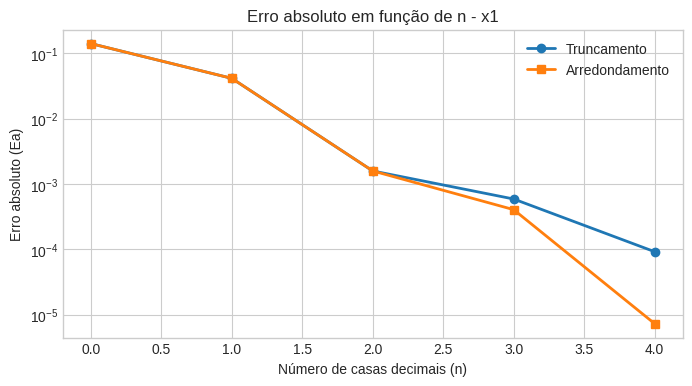

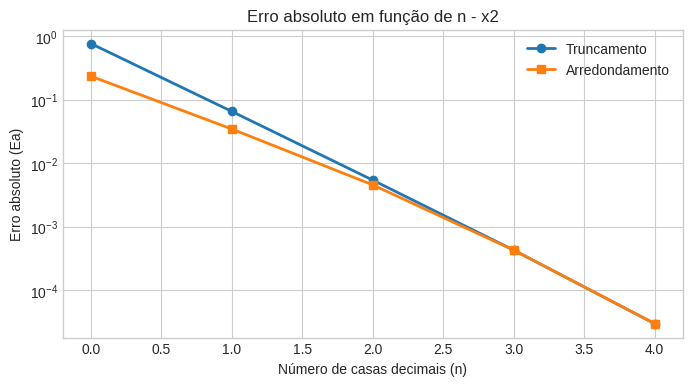

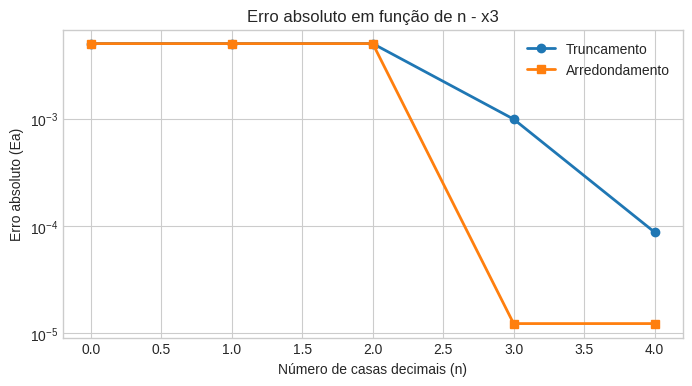

In [ ]:
for indice, valor_referencia in enumerate(valores):

    casas_decimais = [0, 1, 2, 3, 4]

    erros_truncamento = []
    erros_arredondamento = []

    for n in casas_decimais:

        valor_truncado = truncar(valor_referencia, n)

        erro_trunc = abs(
            valor_referencia - valor_truncado
        )

        erros_truncamento.append(erro_trunc)


        valor_arredondado = round(valor_referencia, n)

        erro_arred = abs(
            valor_referencia - valor_arredondado
        )

        erros_arredondamento.append(erro_arred)


    plt.figure(figsize=(8, 4))

    plt.semilogy(
        casas_decimais,
        erros_truncamento,
        marker="o",
        linewidth=2,
        label="Truncamento"
    )

    plt.semilogy(
        casas_decimais,
        erros_arredondamento,
        marker="s",
        linewidth=2,
        label="Arredondamento"
    )

    plt.xlabel("Número de casas decimais (n)")
    plt.ylabel("Erro absoluto (Ea)")

    plt.title(
        f"Erro absoluto em função de n - x{indice + 1}"
    )

    plt.legend()

    plt.show()

### 5. Arredondar sempre gera erro menor que truncamento?

Sempre é menor ou igual, e é igual geralmente com poucas casas como 0, 1, 2

In [ ]:
dados_originais = [121.7,
120.4,
122.1,
119.8,
121.2,
120.9,
122.4,
121.0,
120.2,
121.5 ]


In [ ]:
media_referencia = np.mean(dados_originais)
print(media_referencia)

121.12


In [ ]:
dados_int_round = []
for valor in dados_originais:
  valor_round = round(valor, 0)
  dados_int_round.append(valor_round)

In [ ]:
dados_int_trunc = []
for valor in dados_originais:
  valor_trunc = truncar(valor, 0)
  dados_int_trunc.append(valor_trunc)

In [ ]:
def calcular_estatisticas(dados):

    media = np.mean(dados)

    minimo = np.min(dados)

    maximo = np.max(dados)

    amplitude = maximo - minimo

    desvio_padrao = np.std(dados, ddof=1)

    return media, minimo, maximo, amplitude, desvio_padrao

In [ ]:
series = [
    dados_originais,
    dados_int_round,
    dados_int_trunc,

]

nomes = [
    "Original",
    "Inteiro arredondado",
    "Inteiro truncado",

]

for i in range(len(series)):

    media, minimo, maximo, amplitude, desvio_padrao = calcular_estatisticas(series[i])

    print("\n", nomes[i])
    print("Média =", media)
    print("Mínimo =", minimo)
    print("Máximo =", maximo)
    print("Amplitude =", amplitude)
    print("Desvio-padrão amostral =", desvio_padrao)


 Original
Média = 121.12
Mínimo = 119.8
Máximo = 122.4
Amplitude = 2.6000000000000085
Desvio-padrão amostral = 0.8337332373793856

 Inteiro arredondado
Média = 121.1
Mínimo = 120.0
Máximo = 122.0
Amplitude = 2.0
Desvio-padrão amostral = 0.8755950357709131

 Inteiro truncado
Média = 120.7
Mínimo = 119.0
Máximo = 122.0
Amplitude = 3.0
Desvio-padrão amostral = 0.9486832980505138


In [ ]:
erros_absolutos = []
erros_percentuais = []

for i in range(len(series)):

    media = np.mean(series[i])

    ea = erro_absoluto(media_referencia, media)
    er = erro_relativo(ea, media_referencia)
    ep = erro_percentual(er)

    erros_absolutos.append(ea)
    erros_percentuais.append(ep)

    print("\n", nomes[i])

    print("Média =", media)

    print("Ea =", ea)

    print("Er =", er)

    print("E% =", ep)


 Original
Média = 121.12
Ea = 0.0
Er = 0.0
E% = 0.0

 Inteiro arredondado
Média = 121.1
Ea = 0.020000000000010232
Er = 0.0001651254953765706
E% = 0.01651254953765706

 Inteiro truncado
Média = 120.7
Ea = 0.4200000000000017
Er = 0.003467635402906223
E% = 0.3467635402906223


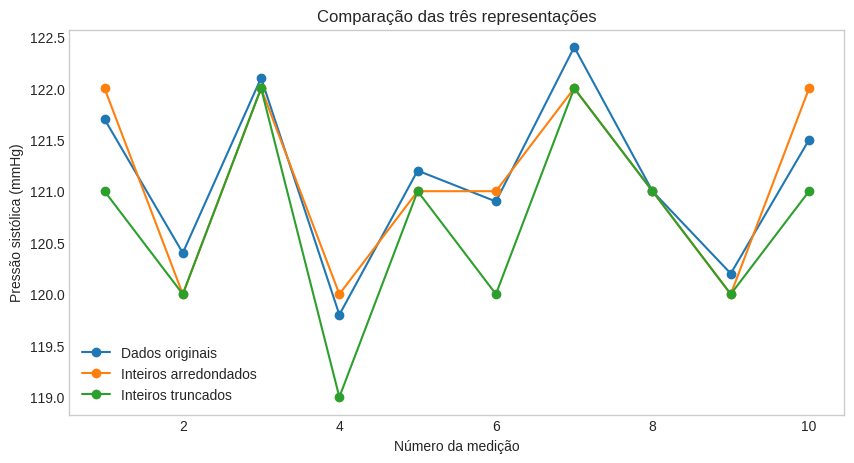

In [ ]:
medicoes = range(1, 11)

plt.figure(figsize=(10, 5))

plt.plot(
    medicoes,
    dados_originais,
    marker="o",
    label="Dados originais"
)

plt.plot(
    medicoes,
    dados_int_round,
    marker="o",
    label="Inteiros arredondados"
)

plt.plot(
    medicoes,
    dados_int_trunc,
    marker="o",
    label="Inteiros truncados"
)


plt.xlabel("Número da medição")

plt.ylabel("Pressão sistólica (mmHg)")

plt.title("Comparação das três representações")

plt.legend()

plt.grid()

plt.show()

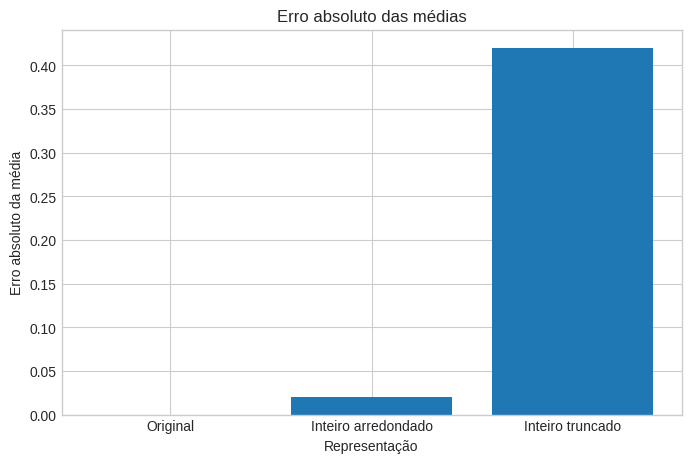

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(
    nomes,
    erros_absolutos
)

plt.xlabel("Representação")

plt.ylabel("Erro absoluto da média")

plt.title("Erro absoluto das médias")

plt.show()

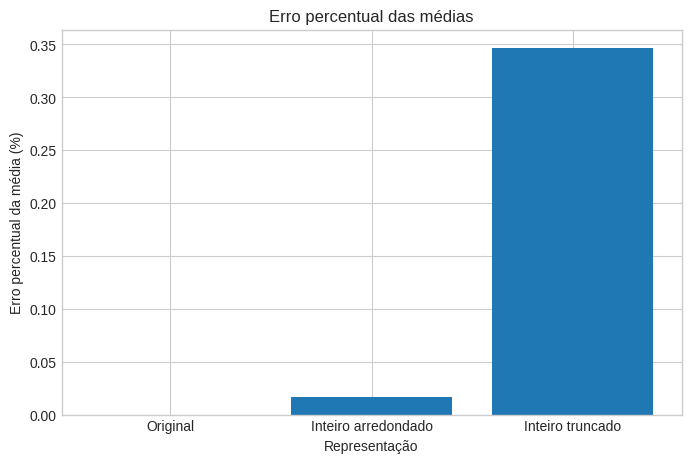

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(
    nomes,
    erros_percentuais
)

plt.xlabel("Representação")

plt.ylabel("Erro percentual da média (%)")

plt.title("Erro percentual das médias")

plt.show()